In [3]:
pip install pandas textblob nltk vaderSentiment scikit-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd

df = pd.read_csv("Amazon_Unlocked_Mobile.csv")

print(df.head())

print(df.columns)


                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  
0       5  I feel so LUCKY to have found this used (phone...           1.0  
1       4  nice phone, nice up grade from my pantach revu...           0.0  
2       5                                       Very pleased           0.0  
3       4  It works good but it goes slow sometimes but i...           0.0  
4       4  Great phone to replace my lost phone. The only...           0.0  
Index(['Product Name', 'Brand Name', 'Price', 'Rating', 'Reviews',
       'Review Votes

In [5]:
pip install textblob


Note: you may need to restart the kernel to use updated packages.


In [3]:
from textblob import TextBlob

def get_sentiment(review):
    analysis = TextBlob(review)
    polarity = analysis.sentiment.polarity  
    
    if polarity > 0:
        return "positive"
    elif polarity < 0:
        return "negative"
    else:
        return "neutral"

df["Sentiment"] = df["Reviews"].astype(str).apply(get_sentiment)
print(df.head())


                                        Product Name Brand Name   Price  \
0  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
1  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
2  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
3  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   
4  "CLEAR CLEAN ESN" Sprint EPIC 4G Galaxy SPH-D7...    Samsung  199.99   

   Rating                                            Reviews  Review Votes  \
0       5  I feel so LUCKY to have found this used (phone...           1.0   
1       4  nice phone, nice up grade from my pantach revu...           0.0   
2       5                                       Very pleased           0.0   
3       4  It works good but it goes slow sometimes but i...           0.0   
4       4  Great phone to replace my lost phone. The only...           0.0   

  Sentiment  
0  positive  
1  positive  
2  positive  
3  positive  
4  positiv

In [4]:
df.to_csv("labeled_mobile_reviews.csv", index=False)
print("Labeled dataset saved as labeled_mobile_reviews.csv!")


Labeled dataset saved as labeled_mobile_reviews.csv!


In [19]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

df["Reviews"] = df["Reviews"].fillna("")
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Reviews"]) 
y = df["Sentiment"]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train ML model
model = LogisticRegression(max_iter=500)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9543543398414847

Classification Report:
               precision    recall  f1-score   support

    negative       0.89      0.81      0.85     10389
     neutral       0.96      0.96      0.96     12092
    positive       0.96      0.98      0.97     60287

    accuracy                           0.95     82768
   macro avg       0.94      0.91      0.92     82768
weighted avg       0.95      0.95      0.95     82768



In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

df["Reviews"] = df["Reviews"].fillna("")

vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df["Reviews"]) 
y = df["Sentiment"]  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_model = RandomForestClassifier(class_weight="balanced", n_estimators=50, max_depth=20, min_samples_split=5, random_state=42)
rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7935313164508022

Classification Report:
               precision    recall  f1-score   support

    negative       0.53      0.80      0.64     10389
     neutral       0.54      0.87      0.67     12092
    positive       0.99      0.78      0.87     60287

    accuracy                           0.79     82768
   macro avg       0.69      0.82      0.72     82768
weighted avg       0.86      0.79      0.81     82768



Average Price for Each Sentiment
Sentiment
negative    200.468945
neutral     217.735865
positive    233.205297
Name: Price, dtype: float64


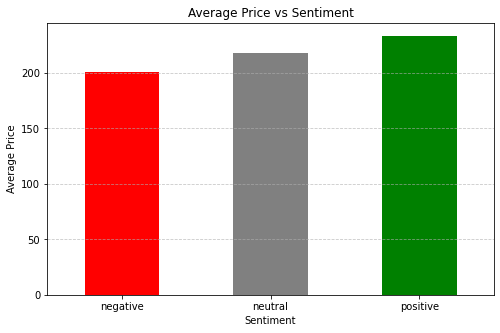

In [4]:
import pandas as pd

df = pd.read_csv("labeled_mobile_reviews.csv")

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price']) 

avg_price_per_sentiment = df.groupby('Sentiment')['Price'].mean()

print("Average Price for Each Sentiment")
print(avg_price_per_sentiment)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
avg_price_per_sentiment.plot(kind='bar', color=['red', 'gray', 'green'])
plt.xlabel('Sentiment')
plt.ylabel('Average Price')
plt.title('Average Price vs Sentiment')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


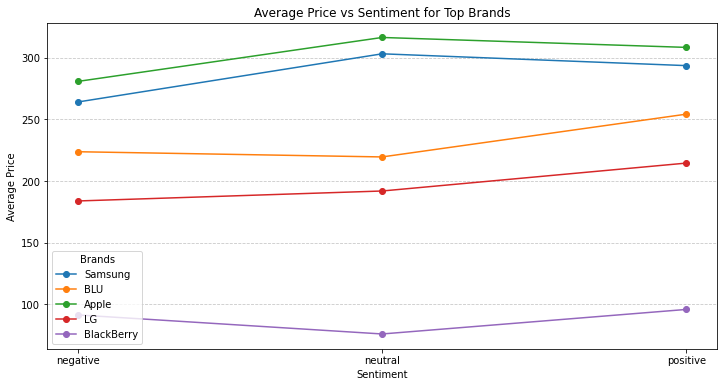

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("labeled_mobile_reviews.csv")

df['Price'] = pd.to_numeric(df['Price'], errors='coerce')
df = df.dropna(subset=['Price', 'Brand Name'])  

top_brands = df['Brand Name'].value_counts().head(5).index
df_top_brands = df[df['Brand Name'].isin(top_brands)]

plt.figure(figsize=(12, 6))

for brand in top_brands:
    brand_data = df_top_brands[df_top_brands['Brand Name'] == brand]
    avg_price_per_sentiment = brand_data.groupby('Sentiment')['Price'].mean()
    
    plt.plot(avg_price_per_sentiment.index, avg_price_per_sentiment.values, marker='o', label=brand)

plt.xlabel('Sentiment')
plt.ylabel('Average Price')
plt.title('Average Price vs Sentiment for Top Brands')
plt.xticks(rotation=0)
plt.legend(title="Brands")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


<Figure size 864x432 with 0 Axes>

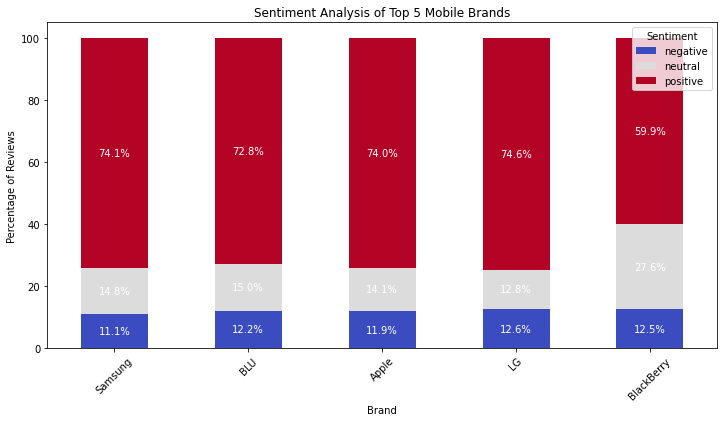

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("labeled_mobile_reviews.csv")

# Select relevant columns
df = df[['Brand Name', 'Sentiment']] 

# Count sentiment per brand
brand_sentiment_counts = df.groupby(['Brand Name', 'Sentiment']).size().unstack(fill_value=0)

# Select top 5 brands based on total number of reviews
top_brands = brand_sentiment_counts.sum(axis=1).nlargest(5).index
brand_sentiment_counts = brand_sentiment_counts.loc[top_brands]

# Convert counts to percentage
brand_sentiment_percentage = brand_sentiment_counts.div(brand_sentiment_counts.sum(axis=1), axis=0) * 100

# Plot the sentiment distribution
plt.figure(figsize=(12, 6))
ax = brand_sentiment_percentage.plot(kind='bar', stacked=True, colormap='coolwarm', figsize=(12, 6))

# Add percentage labels on bars
for p in ax.patches:
    width = p.get_width()  
    height = p.get_height()  
    x, y = p.get_xy() 

    if height > 0: 
        ax.text(x + width / 2, y + height / 2, f'{height:.1f}%', 
                ha='center', va='center', fontsize=10, color='white')

# Customize the plot
plt.title('Sentiment Analysis of Top 5 Mobile Brands')
plt.xlabel('Brand')
plt.ylabel('Percentage of Reviews')
plt.legend(title='Sentiment')
plt.xticks(rotation=45)
plt.show()
